In [1]:
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory
from collections import OrderedDict
import matplotlib.pyplot as plt

# ====================================================
# 1. Global config
# ====================================================
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 1337

root_dir  = Path("chest_xray")
train_dir = root_dir / "train"   # NORMAL, bacteria, virus
test_dir  = root_dir / "test"    # NORMAL, bacteria, virus

AUTOTUNE = tf.data.AUTOTUNE

2025-12-11 19:21:38.235163: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# ====================================================
# 2. Preprocess + prepare helper
# ====================================================
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def prepare(ds, shuffle=False, repeat=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    if repeat:
        ds = ds.repeat()
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds



In [3]:
train_full = image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
    batch_size=None,   # unbatched
)

test_raw = image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    seed=SEED,
    batch_size=None,   # unbatched
)

class_names = train_full.class_names   # ['NORMAL', 'bacteria', 'virus']
print("Model C classes:", class_names)


Found 5232 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Model C classes: ['NORMAL', 'PNEUMONIA']


2025-12-11 19:21:41.167002: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-11 19:21:41.270811: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:83:00.0, compute capability: 7.0


In [4]:
total_train = train_full.cardinality().numpy()
val_size    = int(0.10 * total_train)
train_size  = total_train - val_size

train_raw = train_full.take(train_size)
val_raw   = train_full.skip(train_size)

print("train_size:", train_size, "val_size:", val_size)

# subsets from train_raw
total_train = train_raw.cardinality().numpy()

def make_subset_C(fraction):
    n = int(total_train * fraction)
    subset_raw = train_raw.take(n)
    return prepare(subset_raw, shuffle=True, repeat=False)

train_10  = make_subset_C(0.10)
train_25  = make_subset_C(0.25)
train_50  = make_subset_C(0.50)
train_100 = prepare(train_raw, shuffle=True, repeat=False)

val  = prepare(val_raw,  shuffle=False, repeat=False)
test = prepare(test_raw, shuffle=False, repeat=False)

for xb, yb in test.take(1):
    print("test batch shapes:", xb.shape, yb.shape)

train_size: 4709 val_size: 523
test batch shapes: (32, 224, 224, 3) (32,)


In [5]:
def make_backbone_C():
    return tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",   # still start from ImageNet
        pooling=None,
    )

def make_model_C(load_B_weights_path=None, fine_tune_at=None):
    backbone = make_backbone_C()

    # In Model C we typically unfreeze some top layers for fine‑tuning
    backbone.trainable = True
    if fine_tune_at is not None:
        for layer in backbone.layers[:fine_tune_at]:
            layer.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(3, activation="softmax")(x)  # 3‑class head

    model = models.Model(inputs, outputs)

    # Optionally initialize from Model‑B weights if provided
    if load_B_weights_path is not None:
        print(f"Loading initial weights from {load_B_weights_path}")
        model.load_weights(load_B_weights_path, by_name=True, skip_mismatch=True)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


In [6]:
EPOCHS = 20
c_subsets = {
    "10%": train_10,
    "25%": train_25,
    "50%": train_50,
    "100%": train_100,
}

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)
histories_C = {}
tests_C     = {}
models_C    = OrderedDict()

# Optional: path to best Model‑B weights if you saved per subset
# For example: load_B_weights_path = "B_3class_100%.h5"
load_B_weights_path = None    # set to actual path if you want warm start

# fine_tune_at: index in backbone.layers where you start unfreezing
fine_tune_at = 100            # adjust based on your original Model‑C

for name, train_ds in c_subsets.items():
    print(f"\n=== C (fine‑tuned MobileNetV2) training on {name} of pool ===")
    model = make_model_C(load_B_weights_path=load_B_weights_path,
                         fine_tune_at=fine_tune_at)
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val,
        callbacks=[early_stop]
    )

    histories_C[name] = history.history
    tests_C[name]     = model.evaluate(test, return_dict=True)
    models_C[name]    = model

print("C 3‑class test metrics per subset:", tests_C)


=== C (fine‑tuned MobileNetV2) training on 10% of pool ===
Epoch 1/20


2025-12-11 19:21:53.030716: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8401
2025-12-11 19:21:54.104563: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x56315ac5e380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-11 19:21:54.104595: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-12-11 19:21:54.109801: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-11 19:21:54.211032: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


15/15 [==============================] - 22s 772ms/step - loss: 0.5100 - accuracy: 0.7936 - val_loss: 0.1857 - val_accuracy: 0.9388
Epoch 2/20
15/15 [==============================] - 12s 662ms/step - loss: 0.1648 - accuracy: 0.9383 - val_loss: 0.1336 - val_accuracy: 0.9579
Epoch 3/20
15/15 [==============================] - 12s 650ms/step - loss: 0.0734 - accuracy: 0.9787 - val_loss: 0.1364 - val_accuracy: 0.9426
Epoch 4/20
15/15 [==============================] - 12s 661ms/step - loss: 0.0730 - accuracy: 0.9745 - val_loss: 0.0917 - val_accuracy: 0.9579
Epoch 5/20
15/15 [==============================] - 12s 688ms/step - loss: 0.0362 - accuracy: 0.9872 - val_loss: 0.1225 - val_accuracy: 0.9598
Epoch 6/20
15/15 [==============================] - 12s 664ms/step - loss: 0.0418 - accuracy: 0.9894 - val_loss: 0.1167 - val_accuracy: 0.9618
Epoch 7/20
15/15 [==============================] - 12s 663ms/step - loss: 0.0319 - accuracy: 0.9915 - val_loss: 0.1021 - val_accuracy: 0.9637
Epoch 8/20

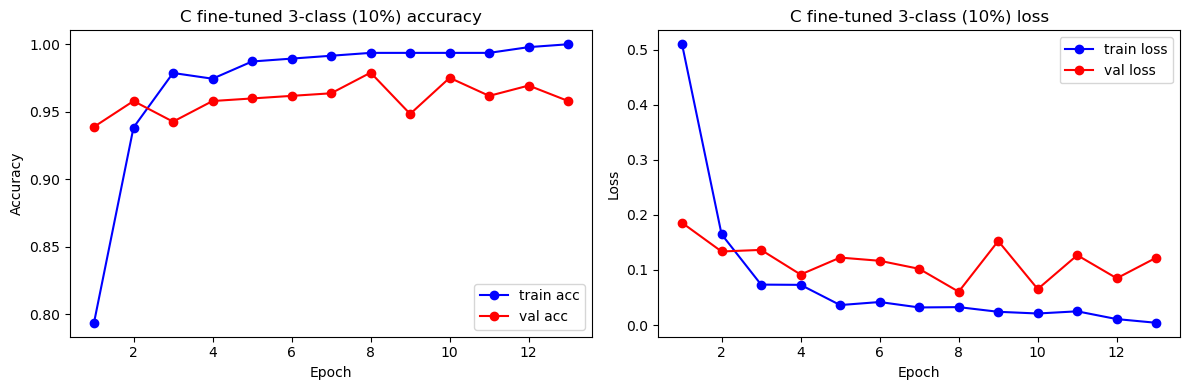

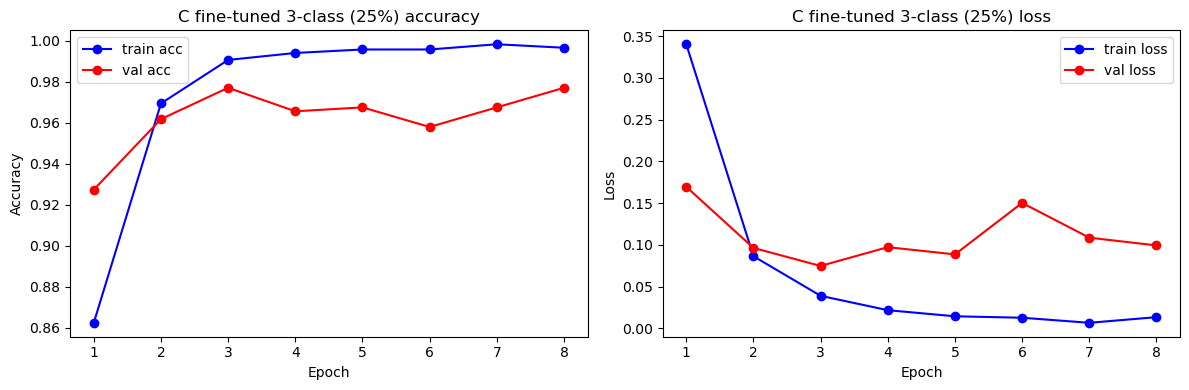

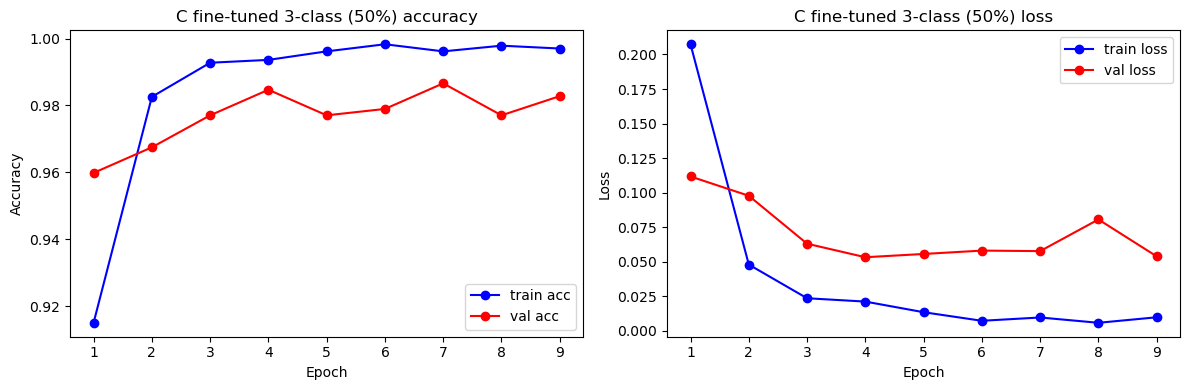

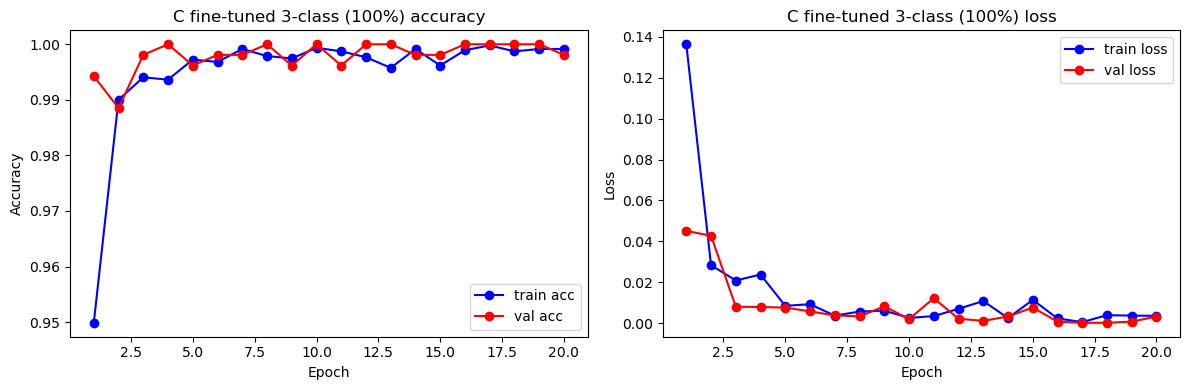

In [7]:
class HistoryWrapper:
    def __init__(self, hist_dict):
        self.history = hist_dict

def plot_history(history, title_prefix="Model"):
    acc      = history.history.get("accuracy", [])
    val_acc  = history.history.get("val_accuracy", [])
    loss     = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    if len(acc) > 0:
        epochs_acc = range(1, len(acc) + 1)
        plt.plot(epochs_acc, acc, "bo-", label="train acc")
    if len(val_acc) > 0:
        epochs_val_acc = range(1, len(val_acc) + 1)
        plt.plot(epochs_val_acc, val_acc, "ro-", label="val acc")
    plt.title(f"{title_prefix} accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    if len(loss) > 0:
        epochs_loss = range(1, len(loss) + 1)
        plt.plot(epochs_loss, loss, "bo-", label="train loss")
    if len(val_loss) > 0:
        epochs_val_loss = range(1, len(val_loss) + 1)
        plt.plot(epochs_val_loss, val_loss, "ro-", label="val loss")
    plt.title(f"{title_prefix} loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()
    
for frac, hist_dict in histories_C.items():
    plot_history(HistoryWrapper(hist_dict),
                 title_prefix=f"C fine‑tuned 3‑class ({frac})")

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

# true labels from unbatched test_raw
y_true_batches = []
for _, labels in test_raw:
    y_true_batches.append(labels.numpy().ravel())
y_true = np.concatenate(y_true_batches, axis=0)
print("y_true shape:", y_true.shape)

for name, model in models_C.items():
    print(f"\n=== C 3‑class test report – subset {name} ===")
    probs  = model.predict(test)
    y_pred = probs.argmax(axis=1)

    print("Classification report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    print("Confusion matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)


y_true shape: (624,)

=== C 3‑class test report – subset 10% ===
20/20 [==============================] - 1s 43ms/step
Classification report:
              precision    recall  f1-score   support

      NORMAL       0.51      0.19      0.28       234
   PNEUMONIA       0.65      0.89      0.75       390

    accuracy                           0.63       624
   macro avg       0.58      0.54      0.51       624
weighted avg       0.60      0.63      0.57       624

Confusion matrix:
[[ 44 190]
 [ 42 348]]

=== C 3‑class test report – subset 25% ===
20/20 [==============================] - 1s 45ms/step
Classification report:
              precision    recall  f1-score   support

      NORMAL       0.53      0.17      0.25       234
   PNEUMONIA       0.65      0.91      0.76       390

    accuracy                           0.63       624
   macro avg       0.59      0.54      0.50       624
weighted avg       0.60      0.63      0.57       624

Confusion matrix:
[[ 39 195]
 [ 35 355]]

